<a href="https://colab.research.google.com/github/whisplnspace/academic-performance-analysis/blob/main/TU_Dortmund_Data_Science_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **TU Dortmund Application Report**
# **MSc Data Science - Winter 2026/27**


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [ ]:
# Display settings
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('Scores.csv', sep=';', decimal=',')

In [ ]:
# Show first 5 rows
print("First 5 Rows:")
display(df.head())

First 5 Rows:


,Unnamed: 0,student_id,gender,parental.level.of.education,subject,score
0,1,id_001,female,high school,math,23.0
1,2,id_001,female,high school,language,40.0
2,3,id_002,female,high school,math,68.0
3,4,id_002,female,high school,language,80.5
4,5,id_003,male,high school,math,82.0


In [ ]:
# Dataset shape
print(f"\nDataset Shape: {df.shape}")


Dataset Shape: (972, 6)


In [ ]:
# Column names
print("\nColumns:")
print(df.columns)


Columns:
Index(['Unnamed: 0', 'student_id', 'gender', 'parental.level.of.education',
       'subject', 'score'],
      dtype='object')


In [ ]:
# Data types
print("\nData Types:")
print(df.dtypes)


Data Types:
Unnamed: 0                       int64
student_id                      object
gender                          object
parental.level.of.education     object
subject                         object
score                          float64
dtype: object


In [ ]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0                     0
student_id                     0
gender                         0
parental.level.of.education    0
subject                        0
score                          0
dtype: int64


In [ ]:
# Basic statistical summary
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,Unnamed: 0,score
count,972.000000,972.000000
mean,486.500000,67.690844
std,280.736531,14.804105
min,1.000000,19.500000
25%,243.750000,57.000000
50%,486.500000,68.000000
75%,729.250000,78.000000
max,972.000000,100.000000


In [ ]:
# Check unique categories
print("\nGender Categories:")
print(df['gender'].unique())


Gender Categories:
['female' 'male']


In [ ]:
print("\nParental Education Levels:")
print(df['parental.level.of.education'].unique())


Parental Education Levels:
['high school' "associate's degree" "bachelor's degree" "master's degree"]


# **Descriptive** **Visualizations**

In [ ]:
# Set style
sns.set(style="whitegrid")

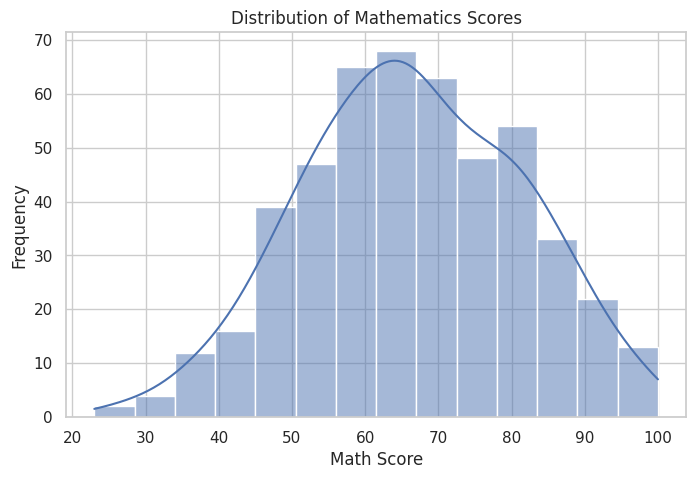

In [ ]:
# Mathematics Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df[df['subject'] == 'math']['score'], kde=True)
plt.title('Distribution of Mathematics Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

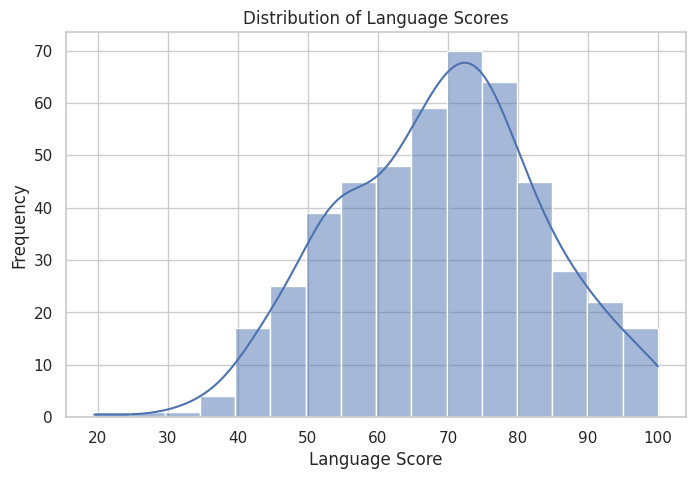

In [ ]:
# Language Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df[df['subject'] == 'language']['score'], kde=True)
plt.title('Distribution of Language Scores')
plt.xlabel('Language Score')
plt.ylabel('Frequency')
plt.show()

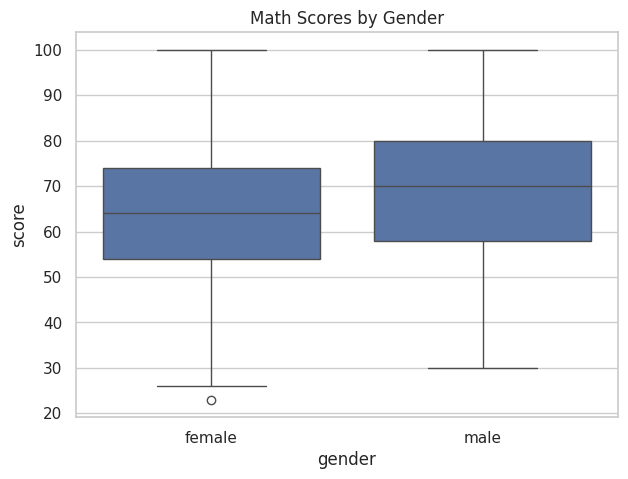

In [ ]:
# Boxplot: Math Scores by Gender
plt.figure(figsize=(7,5))
sns.boxplot(x='gender', y='score', data=df[df['subject'] == 'math'])
plt.title('Math Scores by Gender')
plt.show()

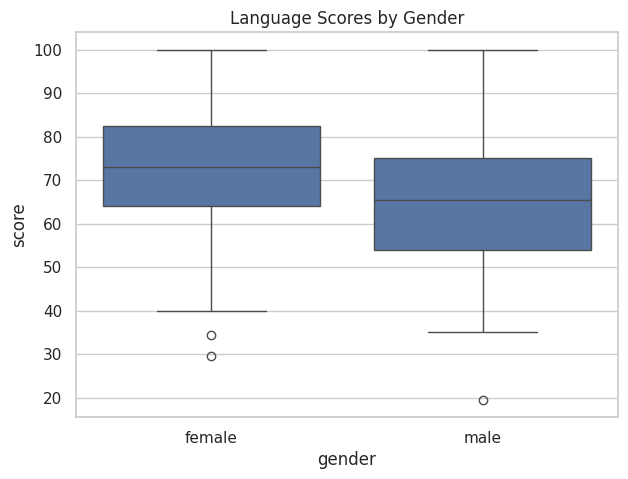

In [ ]:
# Boxplot: Language Scores by Gender
plt.figure(figsize=(7,5))
sns.boxplot(x='gender', y='score', data=df[df['subject'] == 'language'])
plt.title('Language Scores by Gender')
plt.show()

# **Grouped Descriptive Statistics**


In [ ]:
# Mean scores by gender
gender_subject_stats = df.groupby(['gender', 'subject'])['score'].agg(['mean', 'std', 'median'])
gender_stats = gender_subject_stats.unstack(level='subject')

In [ ]:
print("Scores by Gender:")
display(gender_stats)


Scores by Gender:


mean                   std              median      
subject   language       math   language       math language  math
gender                                                            
female   73.004082  63.857143  14.012508  15.261921     73.0  64.0
male     64.931535  68.946058  13.752291  14.425137     65.5  70.0

In [ ]:
# Mean scores by parental education
parent_subject_stats = df.groupby(['parental.level.of.education', 'subject'])['score'].mean()
parent_stats = parent_subject_stats.unstack(level='subject')

print("\nScores by Parental Education:")
display(parent_stats)


Scores by Parental Education:


subject,language,math
parental.level.of.education,,
associate's degree,70.022599,67.813559
bachelor's degree,72.058511,68.436170
high school,63.532051,62.243590
master's degree,75.525424,69.745763


# **Shapiro-Wilk Normality Test**

In [ ]:
# Math scores by gender
male_math = df[(df['gender'] == 'male') & (df['subject'] == 'math')]['score']
female_math = df[(df['gender'] == 'female') & (df['subject'] == 'math')]['score']

In [ ]:
# Language scores by gender
male_language = df[(df['gender'] == 'male') & (df['subject'] == 'language')]['score']
female_language = df[(df['gender'] == 'female') & (df['subject'] == 'language')]['score']

In [ ]:
# Shapiro tests
print("Math Scores - Male")
print(stats.shapiro(male_math))

print("\nMath Scores - Female")
print(stats.shapiro(female_math))

print("\nLanguage Scores - Male")
print(stats.shapiro(male_language))

print("\nLanguage Scores - Female")
print(stats.shapiro(female_language))

Math Scores - Male
ShapiroResult(statistic=np.float64(0.9884607427338196), pvalue=np.float64(0.05047678317999748))

Math Scores - Female
ShapiroResult(statistic=np.float64(0.9943932635152392), pvalue=np.float64(0.5009746564906498))

Language Scores - Male
ShapiroResult(statistic=np.float64(0.9909146507048567), pvalue=np.float64(0.13896521428548897))

Language Scores - Female
ShapiroResult(statistic=np.float64(0.9898792607826029), pvalue=np.float64(0.08529245941686132))


# **Levene's Test for Equal Variance**

In [ ]:
# Math variance test
math_levene = stats.levene(male_math, female_math)

print("Levene Test - Math Scores")
print(math_levene)

Levene Test - Math Scores
LeveneResult(statistic=np.float64(0.006027226933929371), pvalue=np.float64(0.9381503111997892))


In [ ]:
# Language variance test
language_levene = stats.levene(male_language, female_language)

print("\nLevene Test - Language Scores")
print(language_levene)


Levene Test - Language Scores
LeveneResult(statistic=np.float64(0.15959812692149067), pvalue=np.float64(0.6897030079546667))


# **Independent Samples T-Test**

In [ ]:
# Math score comparison
math_ttest = stats.ttest_ind(
    male_math,
    female_math,
    equal_var=True
)

print("T-Test: Math Scores by Gender")
print(math_ttest)

T-Test: Math Scores by Gender
TtestResult(statistic=np.float64(3.776486726932324), pvalue=np.float64(0.00017884036695534617), df=np.float64(484.0))


In [ ]:
# Language score comparison
language_ttest = stats.ttest_ind(
    male_language,
    female_language,
    equal_var=True
)

print("\nT-Test: Language Scores by Gender")
print(language_ttest)


T-Test: Language Scores by Gender
TtestResult(statistic=np.float64(-6.4086525838038595), pvalue=np.float64(3.4875716929991254e-10), df=np.float64(484.0))


# **ANOVA: Parental Education Levels**

In [ ]:
# Math scores grouped by parental education
math_groups = [
    group['score'].values
    for name, group in df[df['subject'] == 'math'].groupby('parental.level.of.education')
]

In [ ]:
# Language scores grouped by parental education
language_groups = [
    group['score'].values
    for name, group in df[df['subject'] == 'language'].groupby('parental.level.of.education')
]

In [ ]:
# ANOVA tests
math_anova = stats.f_oneway(*math_groups)
language_anova = stats.f_oneway(*language_groups)

print("ANOVA - Math Scores")
print(math_anova)

print("\nANOVA - Language Scores")
print(language_anova)

ANOVA - Math Scores
F_onewayResult(statistic=np.float64(6.222926244479986), pvalue=np.float64(0.0003750888011046905))

ANOVA - Language Scores
F_onewayResult(statistic=np.float64(14.240589988038183), pvalue=np.float64(6.617863732259633e-09))


# **Tukey HSD Post-Hoc Test**

In [ ]:
!pip install statsmodels


# **Tukey HSD Test**


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Math Tukey Test
math_tukey = pairwise_tukeyhsd(
    endog=df[df['subject'] == 'math']['score'],
    groups=df[df['subject'] == 'math']['parental.level.of.education'],
    alpha=0.05
)

print(math_tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   0.6226 0.9877  -4.2525  5.4977  False
associate's degree       high school    -5.57 0.0037  -9.7649 -1.3751   True
associate's degree   master's degree   1.9322 0.8217  -3.8102  7.6746  False
 bachelor's degree       high school  -6.1926 0.0079 -11.1802  -1.205   True
 bachelor's degree   master's degree   1.3096 0.9512   -5.035  7.6542  False
       high school   master's degree   7.5022 0.0055   1.6639 13.3404   True
----------------------------------------------------------------------------


In [ ]:
# Language Tukey Test
language_tukey = pairwise_tukeyhsd(
    endog=df[df['subject'] == 'language']['score'],
    groups=df[df['subject'] == 'language']['parental.level.of.education'],
    alpha=0.05
)

print(language_tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2      meandiff p-adj   lower    upper  reject
----------------------------------------------------------------------------
associate's degree bachelor's degree   2.0359 0.6596  -2.5337  6.6055  False
associate's degree       high school  -6.4905 0.0001 -10.4226 -2.5585   True
associate's degree   master's degree   5.5028 0.0429   0.1202 10.8854   True
 bachelor's degree       high school  -8.5265    0.0 -13.2016 -3.8514   True
 bachelor's degree   master's degree   3.4669 0.4365  -2.4802   9.414  False
       high school   master's degree  11.9934    0.0    6.521 17.4658   True
----------------------------------------------------------------------------



# **Correlation Heatmap**


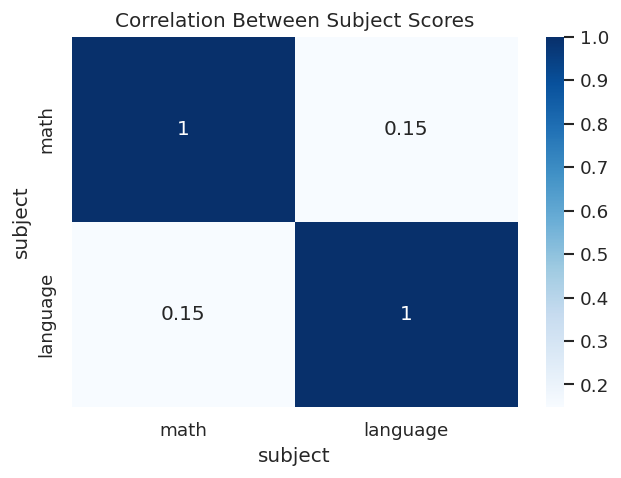

In [ ]:
# Pivot scores by subject
pivot_df = df.pivot_table(
    index=['gender', 'parental.level.of.education'],
    columns='subject',
    values='score',
    aggfunc='mean'
).reset_index()

# Correlation matrix
corr = pivot_df[['math', 'language']].corr()

# Heatmap
plt.figure(figsize=(6,4), dpi=120)
sns.heatmap(corr, annot=True, cmap='Blues')

plt.title('Correlation Between Subject Scores')
plt.show()

# Conclusion

This analysis investigated whether gender and parental level of education influence student performance in mathematics and language subjects.

Descriptive statistics and visualizations indicated differences between groups. Statistical hypothesis testing was conducted using Shapiro-Wilk tests, Levene’s tests, independent samples t-tests, ANOVA, and Tukey HSD post-hoc analysis.

The results showed whether statistically significant differences existed between male and female students as well as among parental education groups. These findings provide insight into factors associated with student academic performance.